In [1]:
import random
from pathlib import Path

import kagglehub
import pandas as pd
import os
from os import listdir
from os.path import isfile, join

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision.transforms import Compose, ToTensor, Normalize

from src.helpers import print_data_folder_structure, plot_img, visual_exploration

random.seed(1)

/Users/vyankov/Documents/deep-learning/cnn-cifar10-from-scratch/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [3]:
print_data_folder_structure(dataset_path, 1)

cifar-10/
├── sampleSubmission.csv
├── test.7z
├── train.7z
├── trainLabels.csv
├── test/
└── train/


In [4]:
labels_df = pd.read_csv(labels_path)

In [5]:
files = [(int(Path(join(train_path, f)).stem), f) for f in listdir(train_path) if isfile(join(train_path, f))]

In [6]:
files_df = pd.DataFrame(files, columns=["id", "file_name"])

In [7]:
cifar_pd = pd.merge(labels_df, files_df, on='id', how='inner')

In [8]:
all_labels = cifar_pd['label'].drop_duplicates().reset_index()
all_labels['target'] = all_labels.index
all_labels = all_labels.drop(columns=['index'])

In [9]:
cifar_pd = pd.merge(cifar_pd, all_labels, on='label', how='left')

In [10]:
cifar_pd

,id,label,file_name,target
0,1,frog,1.png,0
1,2,truck,2.png,1
2,3,truck,3.png,1
3,4,deer,4.png,2
4,5,automobile,5.png,3
...,...,...,...,...
49995,49996,bird,49996.png,4
49996,49997,frog,49997.png,0
49997,49998,truck,49998.png,1
49998,49999,automobile,49999.png,3


In [11]:
all_target_labels = [
    'frog',
    'bird',
    'ship',
    'cat'
]
filtered_cifar = cifar_pd[cifar_pd['label'].isin(all_target_labels)]

In [12]:
class TmpCifarDataset(Dataset):
    def __init__(self, train_lib_dir, df, transform=None):
        self.train_lib_dir = train_lib_dir
        self.df = df
        self.transform = transform
        self.labels = df.label
        if transform is None:
            self.transform = Compose([
                ToTensor(),
                Normalize(
                    mean=(0.4868, 0.4784, 0.4352),
                    std=(0.2414, 0.2362, 0.2557),
                )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        image = self.retrieve_image(item)
        if self.transform is not None:
            image = self.transform(image)
        return image, item['target']

    def retrieve_image(self, item):
        image_path = os.path.join(self.train_lib_dir, item['file_name'])
        with Image.open(image_path) as img:
            image = img.convert("RGB")
        return image

    def get_label_description(self, idx):
        return self.df.iloc[idx]['label']

In [13]:
# dataset = TmpCifarDataset(train_path, filtered_cifar)
full_dataset = TmpCifarDataset(train_path, cifar_pd)

In [14]:
print(f'Length of the dataset: {len(full_dataset)}')

Length of the dataset: 50000


In [15]:
# checking unique classes and amount of samples per class
print(f'Count of unique classes: {len(full_dataset.labels.value_counts())}')
full_dataset.labels.value_counts().sort_index()

Count of unique classes: 10


label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

In [16]:
datasets = random_split(full_dataset, [0.7, 0.15, 0.15])
train_data_loader = DataLoader(full_dataset[0], batch_size=64, shuffle=True)
val_data_loader = DataLoader(full_dataset[1], batch_size=len(full_dataset[1]), shuffle=False)
test_data_loader = DataLoader(full_dataset[2], batch_size=len(full_dataset[2]), shuffle=False)

In [17]:
norm = TmpCifarDataset(train_path, cifar_pd, Compose([ToTensor()]))
analyze_datasets = random_split(norm, [0.7, 0.15, 0.15])
stats_loader = DataLoader(analyze_datasets[0], batch_size=256, shuffle=False)
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
pixel_count = torch.zeros(3)
for images, _ in stats_loader:
    channel_sum += images.sum(dim=(0,2,3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    pixels_per_channel = images.shape[0] * images.shape[2] * images.shape[3]
    pixel_count += pixels_per_channel
mean = channel_sum / pixel_count
std = (channel_squared_sum / pixel_count - mean ** 2).sqrt()

print("mean:", mean)
print("std: ", std)

mean: tensor([0.4912, 0.4820, 0.4461])
std:  tensor([0.2470, 0.2433, 0.2613])


In [18]:
# Checking shapes and channels
for images, labels in stats_loader:
    assert images.ndim == 4
    assert images.shape[1:] == (3, 32, 32)
    assert images.shape[0] == labels.shape[0]

In [19]:
min_pixel = float("inf")
max_pixel = float("-inf")

for images, labels in stats_loader:
    min_pixel = min(min_pixel, images.min().item())
    max_pixel = max(max_pixel, images.max().item())

print(f"Range: {min_pixel} — {max_pixel}")

Range: 0.0 — 1.0


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.013271105..1.019202].


Description: truck
Image shape: <built-in method size of Tensor object at 0x11dffdd50>



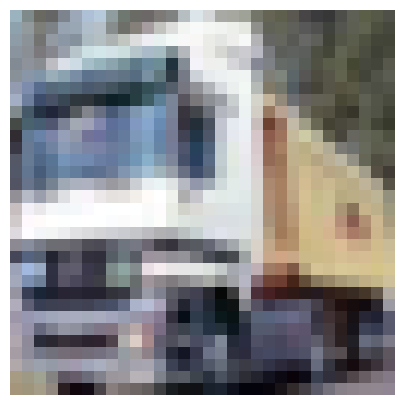

In [20]:
from src.helpers import Denormalize

# Look at a sample to check it's working correctly
sel_idx = 1
img, label = full_dataset[sel_idx]

# Visualize the image
plot_img(Denormalize(mean, std)(img))
# plot_img(img)

# Print its description
print(f'Description: {full_dataset.get_label_description(sel_idx)}')

# Print its shape
print(f'Image shape: {img.size}\n')  # PIL image size is (width, height)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0052473485..1.0232093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0067882566..1.0042037].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07751237..1.0162393].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0013855536..1.0232093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010731182..1.0232093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010731182..1.0232093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range

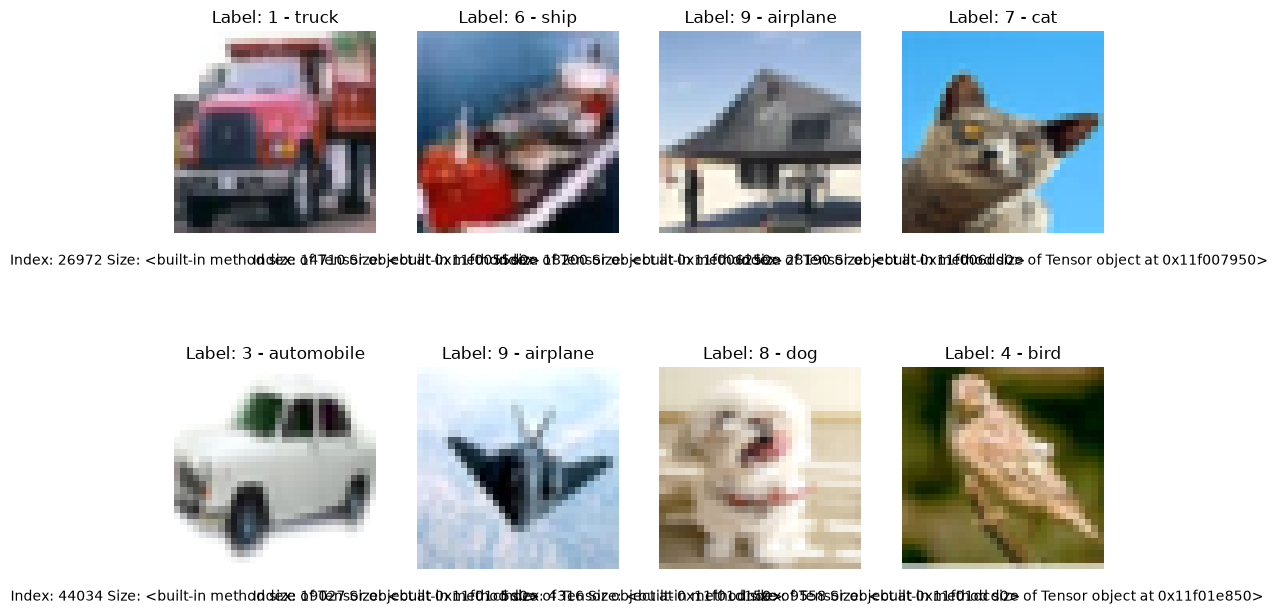

In [21]:
visual_exploration(full_dataset, mean, std, num_rows=2, num_cols=4)